In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from scipy.stats import entropy


In [2]:
path="dataset/match_prediction_features.csv"

df = pd.read_csv(path)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 66 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   match_id                       104 non-null    int64  
 1   date                           104 non-null    str    
 2   kickoff_time_utc               104 non-null    str    
 3   stage_id                       104 non-null    int64  
 4   is_knockout                    104 non-null    int64  
 5   home_team_id                   104 non-null    int64  
 6   home_team_name                 104 non-null    str    
 7   home_fifa_code                 104 non-null    str    
 8   home_confederation             104 non-null    str    
 9   away_team_id                   104 non-null    int64  
 10  away_team_name                 104 non-null    str    
 11  away_fifa_code                 104 non-null    str    
 12  away_confederation             104 non-null    str    
 13  v

In [3]:
ids = ["match_id", "stage_id", "home_team_id", "away_team_id", "venue_id", "referee_id"]
binarias = ["is_knockout", "home_is_host", "away_is_host"]
categoricas = df.select_dtypes(exclude="number").columns.tolist()
numericas = df.select_dtypes("number").columns.difference(ids + binarias, sort=False).tolist()

## ESTADISTICA DESCRIPTIVA

### Variables Numericas

In [4]:
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
venue_capacity,104.0,6.752167e+04,1.197914e+04,3.000000e+04,6.476700e+04,6.979600e+04,7.326900e+04,8.250000e+04
venue_elevation_meters,104.0,2.596635e+02,5.383228e+02,2.000000e+00,7.750000e+00,3.000000e+01,2.640000e+02,2.200000e+03
referee_avg_cards,104.0,4.283654e+00,6.453885e-01,2.900000e+00,3.900000e+00,4.200000e+00,4.800000e+00,5.500000e+00
home_fifa_rank,104.0,2.475962e+01,2.221977e+01,1.000000e+00,6.000000e+00,1.700000e+01,3.900000e+01,8.500000e+01
away_fifa_rank,104.0,3.175962e+01,2.321972e+01,1.000000e+00,1.100000e+01,2.550000e+01,5.100000e+01,8.500000e+01
home_elo,104.0,1.867981e+03,1.720162e+02,1.510000e+03,1.740000e+03,1.850000e+03,2.010000e+03,2.150000e+03
away_elo,104.0,1.810962e+03,1.595246e+02,1.510000e+03,1.687500e+03,1.797500e+03,1.920000e+03,2.150000e+03
home_squad_avg_age,104.0,2.787985e+01,1.080865e+00,2.584900e+01,2.697267e+01,2.777444e+01,2.853994e+01,3.042658e+01
away_squad_avg_age,104.0,2.785269e+01,1.111936e+00,2.584900e+01,2.691476e+01,2.761449e+01,2.864418e+01,3.042658e+01
home_squad_total_caps,104.0,9.368365e+02,2.165284e+02,5.310000e+02,8.027500e+02,9.045000e+02,1.079000e+03,1.586000e+03


#### Forma de la distribución: asimetría y curtosis

In [5]:
forma = pd.DataFrame({
    'asimetria': df[numericas].skew(),
    'curtosis': df[numericas].kurt(),
}).round(2)

# Ordenamos por asimetría absoluta para ver primero las más deformadas
forma.reindex(forma['asimetria'].abs().sort_values(ascending=False).index).head(15)

,asimetria,curtosis
venue_elevation_meters,2.83,7.05
away_squad_total_value_eur,2.16,4.64
away_squad_avg_value_eur,2.16,4.64
away_prev_avg_xg_conceded,2.02,7.05
away_prev_avg_goals_conceded,1.86,4.93
home_prev_avg_saves,1.82,4.64
home_prev_avg_goals_conceded,1.70,3.98
home_prev_avg_xg_conceded,1.63,4.62
venue_capacity,-1.53,2.65
away_prev_avg_corners,1.47,6.23


#### Histogramas

Función auxiliar que grafica el histograma de una variable con su media, asimetría y curtosis.

In [6]:
def plot_histograma(data, column, ax, bins=15, kde=True):
    serie = data[column].dropna()
    sns.histplot(serie, bins=bins, kde=kde, ax=ax, color='steelblue')
    ax.axvline(serie.mean(), color='red', ls='--', lw=2)
    ax.set_title(f'{column}\nAsimetría: {serie.skew():+.2f}  |  Curtosis: {serie.kurt():+.2f}',
                 fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', ls='--', alpha=0.4)

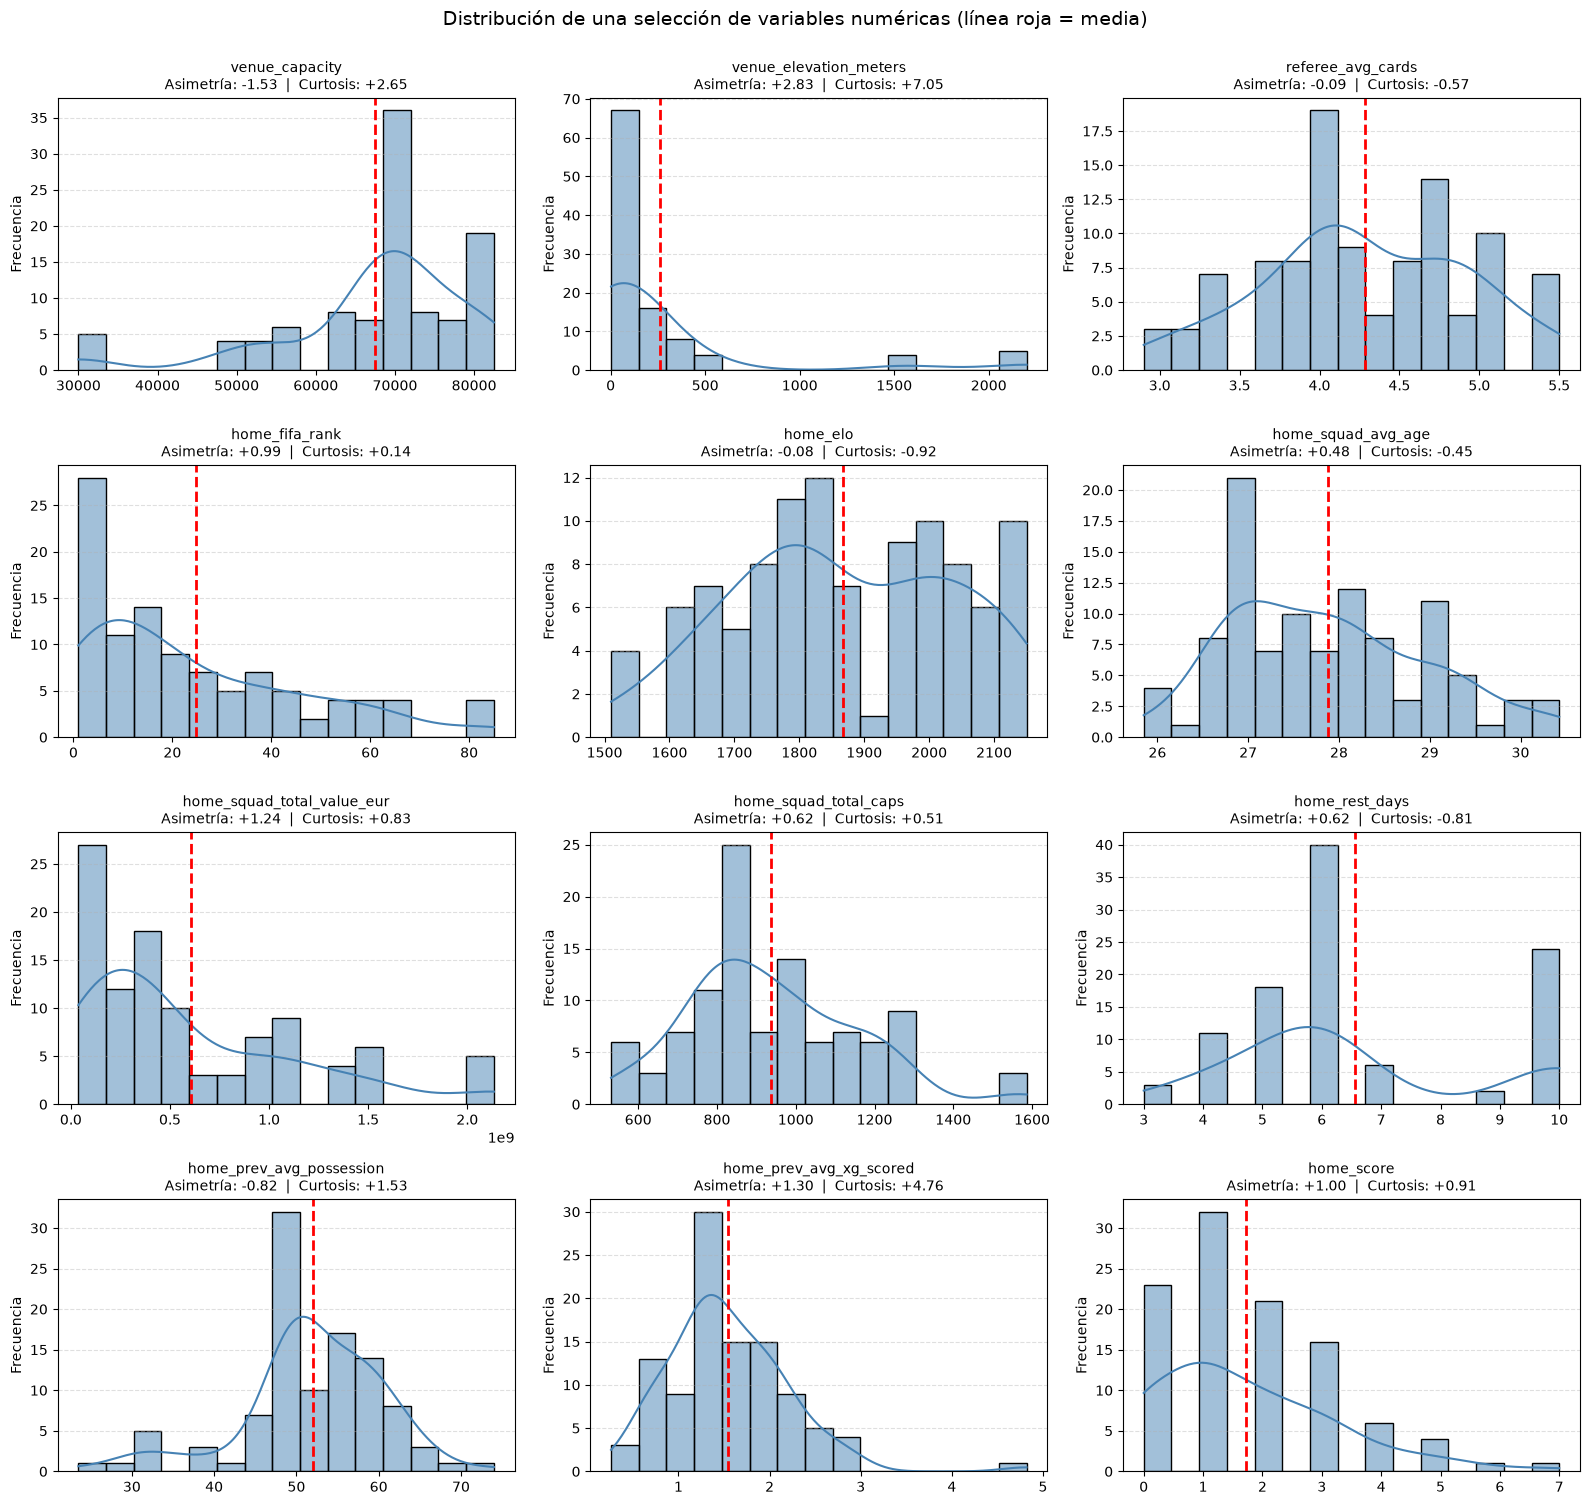

In [7]:
seleccion = [
    'venue_capacity', 'venue_elevation_meters', 'referee_avg_cards',
    'home_fifa_rank', 'home_elo', 'home_squad_avg_age',
    'home_squad_total_value_eur', 'home_squad_total_caps', 'home_rest_days',
    'home_prev_avg_possession', 'home_prev_avg_xg_scored', 'home_score',
]

fig, axes = plt.subplots(4, 3, figsize=(16, 15))
for ax, col in zip(axes.ravel(), seleccion):
    plot_histograma(df, col, ax)

fig.suptitle('Distribución de una selección de variables numéricas (línea roja = media)',
             fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

Lecturas de la forma de las distribuciones:

- **`venue_elevation_meters`** es la más deformada de todas (asimetría **+2,83**, curtosis **+7,05**) y
  claramente **bimodal**: casi todas las sedes están a nivel del mar y unas pocas en el altiplano
  mexicano. No es una distribución "sucia", es geografía.
- **`venue_capacity`** es la única con asimetría negativa fuerte (**−1,53**): la mayoría de los estadios
  son grandes y hay una cola corta de estadios chicos.
- **`home_squad_total_value_eur`** tiene la cola derecha típica de una variable de dinero
  (asimetría **+1,24**): unas pocas selecciones europeas concentran casi todo el valor de mercado.
  Es candidata a una transformación logarítmica.
- **`home_elo`** y **`referee_avg_cards`** son prácticamente simétricas (asimetría ≈ 0) y con curtosis
  negativa: distribuciones chatas, sin colas.
- **`home_prev_avg_possession`** tiene un pico rarísimo justo en 50 % y **`home_prev_avg_xg_scored`** otro
  en 1,3. No es casualidad ni forma natural: es la pista que vamos a seguir en la sección 4.

### Variables Categóricas

In [8]:
df[categoricas].describe().T

,count,unique,top,freq
date,104,35,2026-06-26,6
kickoff_time_utc,104,21,18:00,23
home_team_name,104,48,France,6
home_fifa_code,104,48,FRA,6
home_confederation,104,6,UEFA,45
away_team_name,104,48,Morocco,5
away_fifa_code,104,48,MAR,5
away_confederation,104,6,UEFA,35
stadium_name,104,16,Dallas Stadium (AT&T Stadium),9
venue_city,104,16,Arlington,9


#### Frecuencias

In [9]:
for col in ['home_confederation', 'venue_country', 'result_type', 'match_result']:
    print(f'--- {col} ---')
    print(df[col].value_counts().to_string())
    print()

--- home_confederation ---
home_confederation
UEFA        45
CONMEBOL    18
CONCACAF    15
CAF         13
AFC         11
OFC          2

--- venue_country ---
venue_country
USA    80
MEX    13
CAN    11

--- result_type ---
result_type
Regular      96
AET           5
Penalties     3

--- match_result ---
match_result
H    50
A    30
D    24



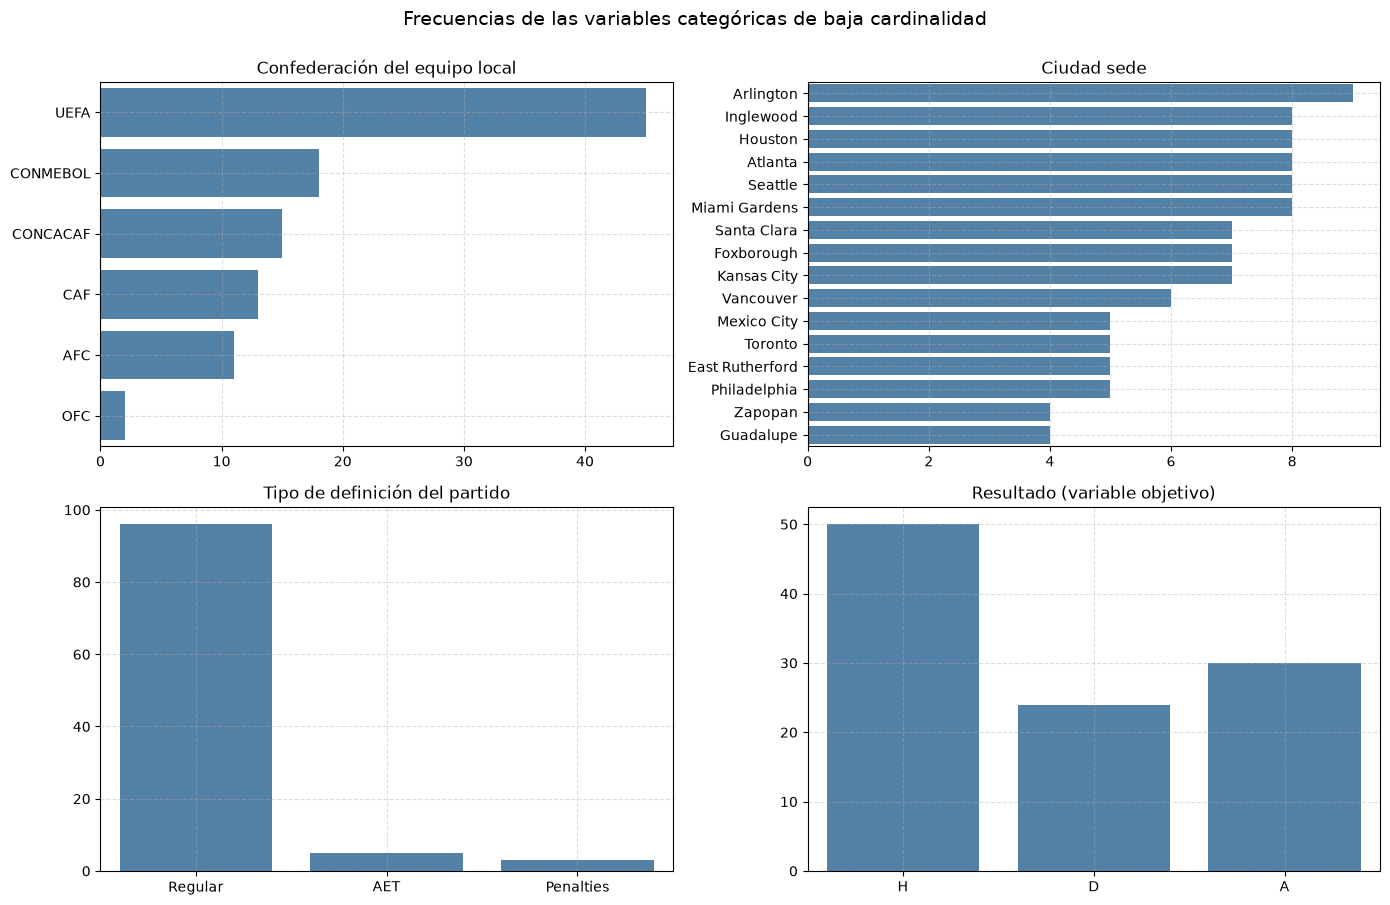

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.countplot(y='home_confederation', data=df, ax=axes[0, 0],
              order=df['home_confederation'].value_counts().index, color='steelblue')
axes[0, 0].set_title('Confederación del equipo local')

sns.countplot(y='venue_city', data=df, ax=axes[0, 1],
              order=df['venue_city'].value_counts().index, color='steelblue')
axes[0, 1].set_title('Ciudad sede')

sns.countplot(x='result_type', data=df, ax=axes[1, 0],
              order=df['result_type'].value_counts().index, color='steelblue')
axes[1, 0].set_title('Tipo de definición del partido')

sns.countplot(x='match_result', data=df, ax=axes[1, 1],
              order=['H', 'D', 'A'], color='steelblue')
axes[1, 1].set_title('Resultado (variable objetivo)')

for ax in axes.ravel():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(ls='--', alpha=0.4)

fig.suptitle('Frecuencias de las variables categóricas de baja cardinalidad', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

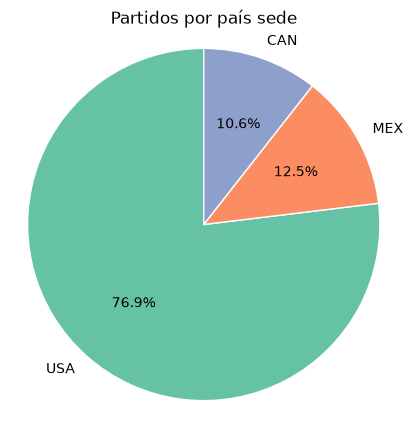

In [11]:
plt.figure(figsize=(5, 5))
conteo_pais = df['venue_country'].value_counts()

plt.pie(conteo_pais.values, labels=conteo_pais.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(conteo_pais)),
        startangle=90, wedgeprops=dict(edgecolor='white'))
plt.title('Partidos por país sede')
plt.axis('equal')
plt.show()

#### Entropía

La entropía de Shannon mide qué tan repartidas están las categorías. Comparada contra su máximo
(`log2(k)`, que se alcanza cuando todas las categorías son igual de frecuentes) da un cociente entre 0
(una sola categoría se lleva todo) y 1 (reparto perfectamente uniforme).

In [12]:
resumen_cat = []
for col in categoricas:
    conteo = df[col].value_counts()
    p = conteo / conteo.sum()
    k = df[col].nunique()
    H = entropy(p, base=2)
    resumen_cat.append({
        'variable': col,
        'cardinalidad': k,
        'moda': conteo.index[0],
        'frec_moda': conteo.iloc[0],
        'H': round(H, 2),
        'H_max': round(np.log2(k), 2),
        'H/H_max': round(H / np.log2(k), 2),
    })

pd.DataFrame(resumen_cat).sort_values('H/H_max').reset_index(drop=True)

,variable,cardinalidad,moda,frec_moda,H,H_max,H/H_max
0,result_type,3,Regular,96,0.46,1.58,0.29
1,venue_country,3,USA,80,1.01,1.58,0.64
2,kickoff_time_utc,21,18:00,23,3.57,4.39,0.81
3,home_confederation,6,UEFA,45,2.19,2.58,0.85
4,away_confederation,6,UEFA,35,2.21,2.58,0.85
5,match_result,3,H,50,1.51,1.58,0.95
6,date,35,2026-06-26,6,4.93,5.13,0.96
7,home_team_name,48,France,6,5.34,5.58,0.96
8,home_fifa_code,48,FRA,6,5.34,5.58,0.96
9,away_team_name,48,Morocco,5,5.44,5.58,0.97


Lecturas:

- **`result_type` es la más concentrada** (H/H_max = **0,29**): 96 de 104 partidos se definieron en los
  90 minutos. Como variable predictora aporta poquísimo, y además solo se conoce *después* del partido.
- **`venue_country`** también está desbalanceada (**0,64**): **80 de 104 partidos se juegan en Estados
  Unidos**, contra 13 en México y 11 en Canadá. Si se quisiera modelar una "ventaja de sede", el país
  casi no discrimina.
- **`venue_city`, `referee_name` y `home_team_name` están en entropía casi máxima** (0,96–0,99). Tiene
  sentido: el fixture de un Mundial se diseña justamente para repartir equipos, sedes y árbitros de
  manera pareja. No es una propiedad de los datos, es una propiedad del torneo.
- **`match_result`** da **0,95**: la variable objetivo está razonablemente balanceada (48 % / 23 % / 29 %),
  lo cual es una buena noticia para clasificar.
- **`home_confederation`** da 0,85, con UEFA aportando 45 de los 104 locales.

## 2. Tipos de variables

In [13]:
df[numericas].info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 43 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   venue_capacity                 104 non-null    int64  
 1   venue_elevation_meters         104 non-null    float64
 2   referee_avg_cards              104 non-null    float64
 3   home_fifa_rank                 104 non-null    int64  
 4   away_fifa_rank                 104 non-null    int64  
 5   home_elo                       104 non-null    float64
 6   away_elo                       104 non-null    float64
 7   home_squad_avg_age             104 non-null    float64
 8   away_squad_avg_age             104 non-null    float64
 9   home_squad_total_caps          104 non-null    int64  
 10  away_squad_total_caps          104 non-null    int64  
 11  home_squad_total_value_eur     104 non-null    float64
 12  away_squad_total_value_eur     104 non-null    float64
 13  h

In [14]:
df[categoricas].info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   date                104 non-null    str  
 1   kickoff_time_utc    104 non-null    str  
 2   home_team_name      104 non-null    str  
 3   home_fifa_code      104 non-null    str  
 4   home_confederation  104 non-null    str  
 5   away_team_name      104 non-null    str  
 6   away_fifa_code      104 non-null    str  
 7   away_confederation  104 non-null    str  
 8   stadium_name        104 non-null    str  
 9   venue_city          104 non-null    str  
 10  venue_country       104 non-null    str  
 11  referee_name        104 non-null    str  
 12  result_type         104 non-null    str  
 13  match_result        104 non-null    str  
dtypes: str(14)
memory usage: 11.5 KB



### Identificadores (6)

Son `int64`, pero funcionan como etiquetas.

| Variable | dtype | Valores únicos | Identifica |
|---|---|---|---|
| `match_id` | int64 | 104 | Cada partido (clave primaria) |
| `stage_id` | int64 | 7 | Fase del torneo |
| `home_team_id` | int64 | 48 | Selección local |
| `away_team_id` | int64 | 48 | Selección visitante |
| `venue_id` | int64 | 16 | Estadio |
| `referee_id` | int64 | 28 | Árbitro |


### Categóricas nominales (11)

Sin orden intrínseco entre sus categorías.

| Variable | dtype | Valores únicos | Cardinalidad |
|---|---|---|---|
| `home_team_name` / `away_team_name` | str | 48 | Alta |
| `home_fifa_code` / `away_fifa_code` | str | 48 | Alta |
| `home_confederation` / `away_confederation` | str | 6 | Baja |
| `stadium_name` | str | 16 | Media |
| `venue_city` | str | 16 | Media |
| `venue_country` | str | 3 | Baja |
| `referee_name` | str | 28 | Media |
| `match_result` | str | 3 | Baja (variable objetivo) |

### Categóricas ordinales (1)

Sus categorías siguen una progresión natural.

| Variable | dtype | Categorías | Criterio de orden |
|---|---|---|---|
| `result_type` | str | Regular, AET, Penalties | Hasta dónde llegó el partido: 90 minutos → tiempo suplementario → definición por penales |

### Numéricas

**Discretas (5)** — se cuentan, toman valores enteros:

| Variable | dtype |
|---|---|
| `venue_capacity` | int64 |
| `home_squad_total_caps` / `away_squad_total_caps` | int64 |
| `home_score` / `away_score` | int64 |

**Continuas (36)** — admiten cualquier valor dentro de un rango:

| Grupo | Cantidad | Ejemplos |
|---|---|---|
| Contexto del partido | 3 | `venue_elevation_meters`, `referee_avg_cards` |
| Fuerza del equipo | 2 | `home_elo`, `away_elo` |
| Características del plantel | 6 | `home_squad_avg_age`, `home_squad_total_value_eur` |
| Descanso previo | 2 | `home_rest_days`, `away_rest_days` |
| Rendimiento previo (`prev_avg_*`) | 21 | `home_prev_avg_possession`, `away_prev_avg_shots` |
| Goles esperados del partido | 2 | `home_xg`, `away_xg` |


## 3. Relación entre variables

Hasta acá cada variable se analizó por separado. En esta sección se estudia cómo se relacionan
entre sí, combinando los tres cruces posibles según el tipo de variable.

### 3.1 Numérica – numérica

Se compara el **valor total del plantel** con el **rating Elo** del equipo local, para ver si el
poder económico de una selección se corresponde con su fuerza deportiva.

Correlación: 0.842


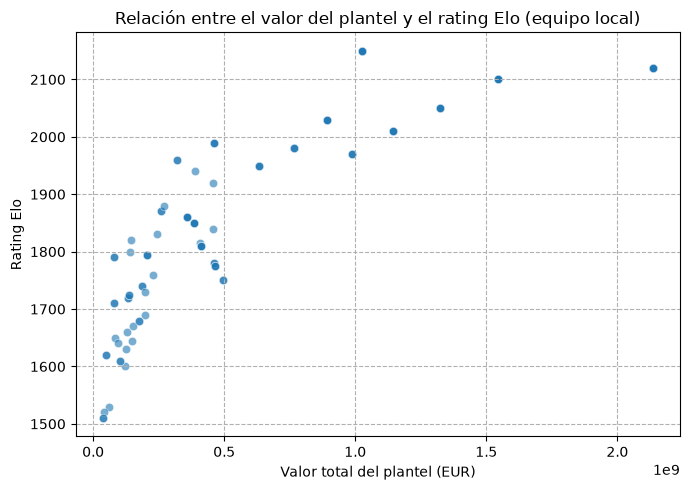

In [15]:
print("Correlación:", df["home_squad_total_value_eur"].corr(df["home_elo"]).round(3))

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='home_squad_total_value_eur', y='home_elo', alpha=0.6)
plt.grid(ls='--')
plt.title('Relación entre el valor del plantel y el rating Elo (equipo local)')
plt.xlabel('Valor total del plantel (EUR)')
plt.ylabel('Rating Elo')
plt.tight_layout()
plt.show()

### 3.2 Numéricas – categórica

Pairplot de cuatro variables numéricas usando como `hue` la variable objetivo `match_result`
(H = gana local, D = empate, A = gana visitante). Permite ver si los resultados se separan
según la fuerza de los equipos.

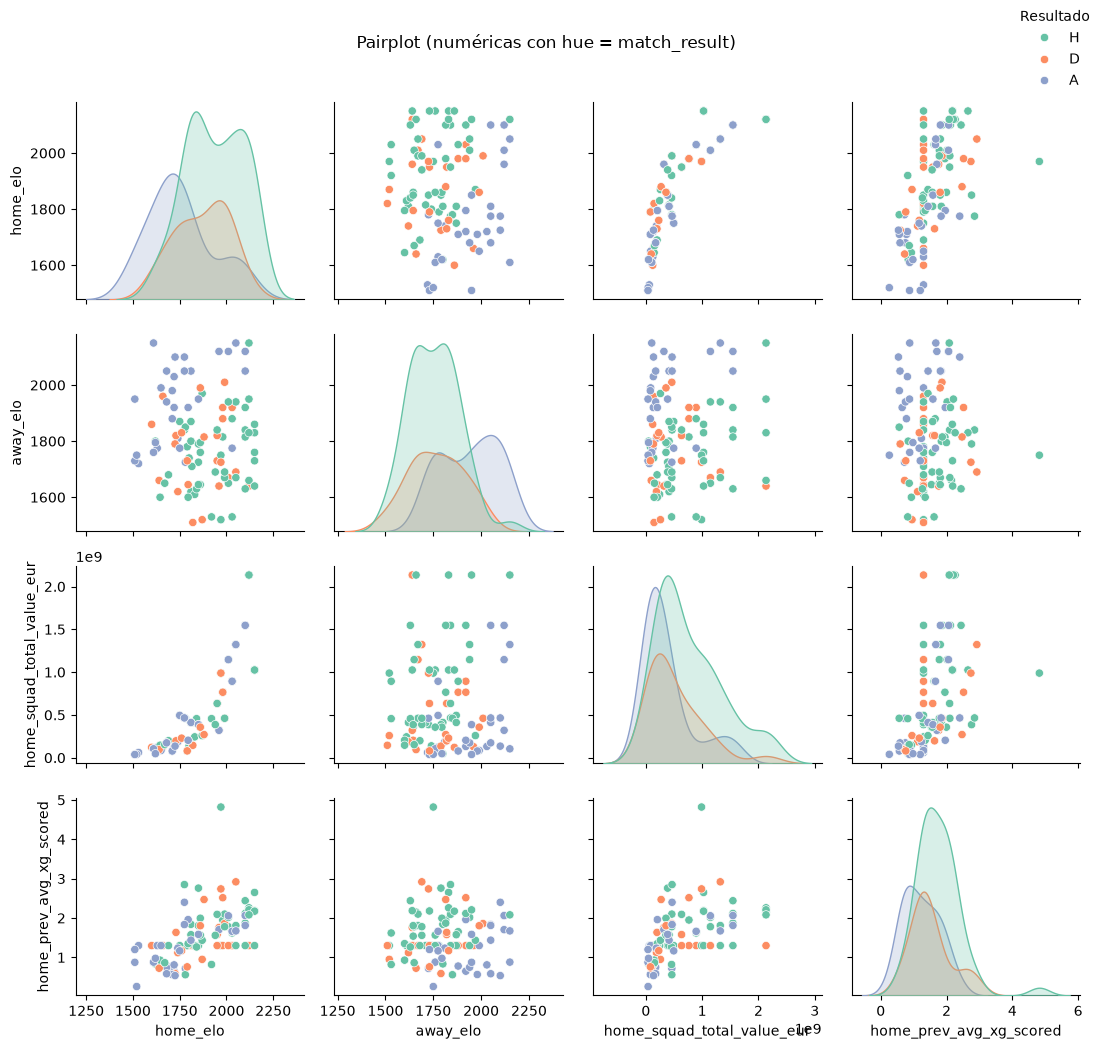

In [16]:
cols = ['home_elo', 'away_elo', 'home_squad_total_value_eur', 'home_prev_avg_xg_scored', 'match_result']

grafico = sns.pairplot(data=df[cols], hue='match_result', palette='Set2')
grafico.figure.suptitle('Pairplot (numéricas con hue = match_result)', y=1.02)

grafico.legend.set_bbox_to_anchor((1, 1))
grafico.legend.set_title('Resultado')

plt.tight_layout()
plt.show()

### 3.3 Categórica – categórica

¿El resultado del partido depende de la confederación a la que pertenece el equipo local?

match_result         A   D   H
home_confederation            
AFC                  4   5   2
CAF                  4   3   6
CONCACAF             7   1   7
CONMEBOL             3   5  10
OFC                  2   0   0
UEFA                10  10  25


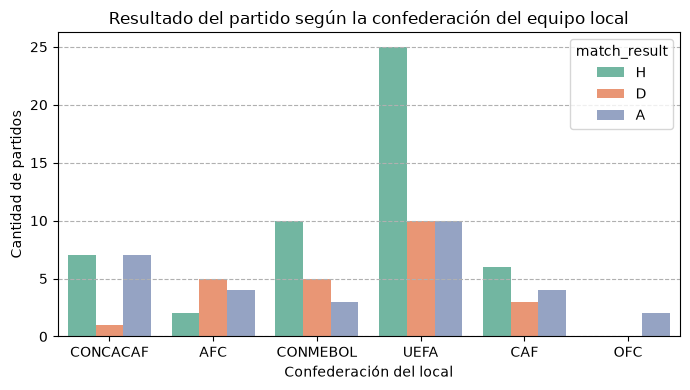

In [17]:
print(pd.crosstab(df['home_confederation'], df['match_result']))

plt.figure(figsize=(7, 4))
sns.countplot(x='home_confederation', hue='match_result', data=df, palette='Set2')
plt.grid(ls='--', axis='y')
plt.title('Resultado del partido según la confederación del equipo local')
plt.xlabel('Confederación del local')
plt.ylabel('Cantidad de partidos')
plt.tight_layout()
plt.show()

## 4. Datos faltantes

### 4.1 Faltantes explícitos

Primer paso obligatorio: contar los `NaN` de cada columna y su porcentaje sobre el total de filas.

In [18]:
faltantes_df = df.isna().sum().to_frame(name='faltantes')
faltantes_df['porcentaje'] = ((faltantes_df['faltantes'] / len(df)) * 100).round(2)
faltantes_df = faltantes_df.sort_values(by='faltantes', ascending=False)

print(f"Celdas totales: {df.size}  |  Celdas nulas: {int(df.isna().sum().sum())}")

# Mostramos solo las columnas que tienen valores faltantes
faltantes_df[faltantes_df['faltantes'] > 0]

Celdas totales: 6864  |  Celdas nulas: 0


,faltantes,porcentaje


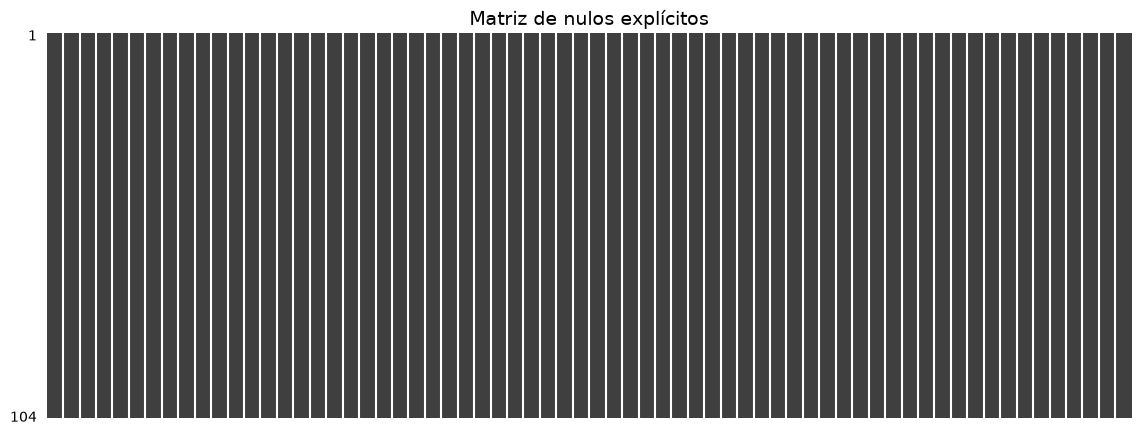

In [19]:
msno.matrix(df, figsize=(14, 5), sparkline=False, fontsize=8)
plt.title('Matriz de nulos explícitos', fontsize=14)
plt.show()

La tabla sale vacía y la matriz es un bloque negro sólido: **no hay un solo `NaN` en las 104 × 66 = 6864 celdas**.

Eso no significa que no falten datos. Este archivo no es un volcado crudo, es la salida de un script de
*feature engineering*: cuando el script no tenía un valor disponible, en lugar de dejar el hueco escribió
un número. Esos son los **faltantes disfrazados** (*disguised missing data*) y son más peligrosos que un
`NaN`, porque ninguna herramienta los marca como problema.

### 4.2 Búsqueda de faltantes disfrazados

Las 22 columnas `*_prev_avg_*` son **promedios de los partidos anteriores del equipo en el torneo**.
Para el primer partido de una selección no existe ningún partido anterior, así que ahí el promedio
es imposible de calcular. Veamos con qué lo rellenaron.

In [20]:
prev_home = [c for c in df.columns if c.startswith('home_prev_avg')]
prev_away = [c for c in df.columns if c.startswith('away_prev_avg')]

# Sospecha: una posesión previa de exactamente 50.0 % es un valor "neutro" demasiado redondo
candidatas = df.loc[df['home_prev_avg_possession'] == 50.0, prev_home].drop_duplicates()

print(f"Filas con posesión previa == 50.0: {(df['home_prev_avg_possession'] == 50.0).sum()}")
print(f"Combinaciones distintas de valores en esas filas: {len(candidatas)}")
candidatas

Filas con posesión previa == 50.0: 24
Combinaciones distintas de valores en esas filas: 1


,home_prev_avg_goals_scored,home_prev_avg_goals_conceded,home_prev_avg_possession,home_prev_avg_shots,home_prev_avg_shots_on_target,home_prev_avg_saves,home_prev_avg_corners,home_prev_avg_fouls,home_prev_avg_offsides,home_prev_avg_xg_scored,home_prev_avg_xg_conceded
0,0.0,0.0,50.0,12.0,4.0,3.0,5.0,12.0,2.0,1.3,1.3


Todas esas filas comparten **exactamente el mismo vector de valores** en las 11 variables previas.
Es la firma de un valor por defecto codificado a mano (posesión 50 %, 12 remates, 4 al arco, 3 atajadas,
5 córners, 12 faltas, 2 offsides, xG 1.3). Contemos cuántas columnas coincide cada fila con ese patrón.

In [21]:
patron_home = candidatas.iloc[0].values
patron_away = df.loc[df['away_prev_avg_possession'] == 50.0, prev_away].drop_duplicates().iloc[0].values

coincidencias_home = (df[prev_home] == patron_home).sum(axis=1)
coincidencias_away = (df[prev_away] == patron_away).sum(axis=1)

print("Columnas que coinciden con el patrón por defecto (equipo local):")
print(coincidencias_home.value_counts().sort_index().to_string())

Columnas que coinciden con el patrón por defecto (equipo local):
0     37
1     27
2     10
3      3
4      3
11    24


La distribución tiene un **hueco limpio**: hay filas que coinciden en 0–4 columnas por pura casualidad
y un grupo de 24 filas que coincide en las **11 de 11**. No hay nada intermedio, así que la regla de
detección no es ambigua.

In [22]:
debut_local = coincidencias_home == len(prev_home)
debut_visitante = coincidencias_away == len(prev_away)

print(f"Partidos con el local debutando:     {debut_local.sum()}")
print(f"Partidos con el visitante debutando: {debut_visitante.sum()}")
print()
print(pd.crosstab(debut_local, debut_visitante,
                  rownames=['debut local'], colnames=['debut visitante']))

Partidos con el local debutando:     24
Partidos con el visitante debutando: 24

debut visitante  False  True 
debut local                  
False               80      0
True                 0     24


Los faltantes no están repartidos: o **faltan los dos equipos o no falta ninguno**. Las 24 filas
afectadas son los 24 partidos de la primera fecha, donde ambas selecciones debutan.

In [23]:
equipos_debut = pd.concat([df.loc[debut_local, 'home_team_name'],
                           df.loc[debut_visitante, 'away_team_name']])
equipos_totales = pd.concat([df['home_team_name'], df['away_team_name']])

print(f"Equipos que debutan: {equipos_debut.nunique()} de {equipos_totales.nunique()} selecciones")
print(f"¿Coincide siempre con rest_days == 10? {(df['home_rest_days'].eq(10) == debut_local).all()}")

df.loc[debut_local, ['date', 'stage_id', 'home_team_name', 'away_team_name',
                     'home_rest_days', 'home_prev_avg_xg_scored']].head(10)

Equipos que debutan: 48 de 48 selecciones
¿Coincide siempre con rest_days == 10? True


,date,stage_id,home_team_name,away_team_name,home_rest_days,home_prev_avg_xg_scored
0,2026-06-11,1,Mexico,South Africa,10.0,1.3
1,2026-06-11,1,South Korea,Czechia,10.0,1.3
2,2026-06-12,1,Canada,Bosnia and Herzegovina,10.0,1.3
3,2026-06-12,1,USA,Paraguay,10.0,1.3
4,2026-06-13,1,Qatar,Switzerland,10.0,1.3
5,2026-06-13,1,Brazil,Morocco,10.0,1.3
6,2026-06-13,1,Haiti,Scotland,10.0,1.3
7,2026-06-13,1,Australia,Türkiye,10.0,1.3
8,2026-06-14,1,Germany,Curaçao,10.0,1.3
9,2026-06-14,1,Netherlands,Japan,10.0,1.3


Las 48 selecciones aparecen exactamente una vez como debutantes, y el debut coincide **al 100 %** con
`rest_days == 10` (los 10 días de descanso son otro valor por defecto: nadie jugó antes, así que no hay
partido previo desde el cual contar).

### 4.3 Reconstrucción: los faltantes como `NaN`

Reemplazamos los valores por defecto por `NaN` para poder analizarlos con las herramientas habituales.

In [24]:
df_nan = df.copy()
df_nan.loc[debut_local, prev_home] = np.nan
df_nan.loc[debut_visitante, prev_away] = np.nan

faltantes_df = df_nan.isna().sum().to_frame(name='faltantes')
faltantes_df['porcentaje'] = ((faltantes_df['faltantes'] / len(df_nan)) * 100).round(2)
faltantes_df = faltantes_df.sort_values(by='faltantes', ascending=False)

print(f"Celdas nulas reales: {int(df_nan.isna().sum().sum())} "
      f"({100 * df_nan.isna().sum().sum() / df_nan.size:.1f} % del dataset)")
faltantes_df[faltantes_df['faltantes'] > 0]

Celdas nulas reales: 528 (7.7 % del dataset)


,faltantes,porcentaje
home_prev_avg_corners,24,23.08
away_prev_avg_fouls,24,23.08
away_prev_avg_possession,24,23.08
home_prev_avg_shots,24,23.08
away_prev_avg_shots,24,23.08
home_prev_avg_shots_on_target,24,23.08
away_prev_avg_shots_on_target,24,23.08
home_prev_avg_saves,24,23.08
away_prev_avg_saves,24,23.08
away_prev_avg_goals_scored,24,23.08


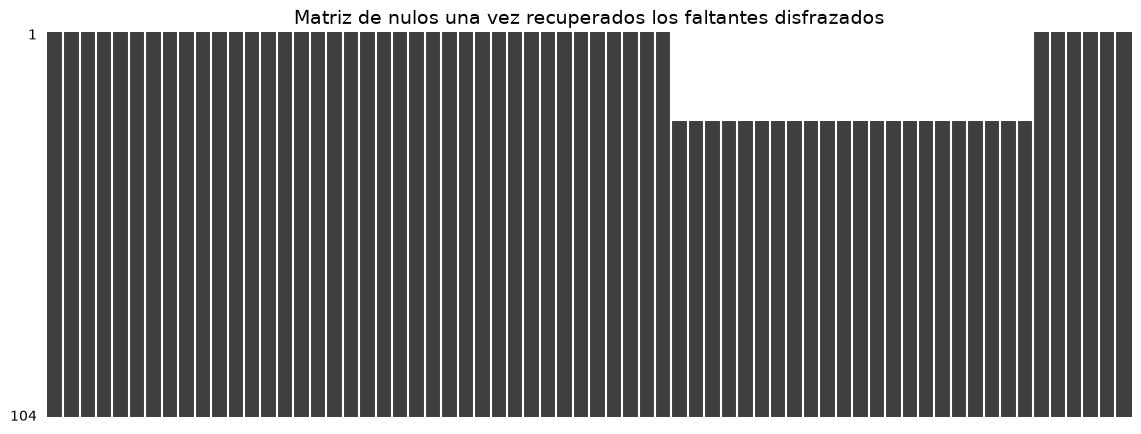

In [25]:
msno.matrix(df_nan, figsize=(14, 5), sparkline=False, fontsize=8)
plt.title('Matriz de nulos una vez recuperados los faltantes disfrazados', fontsize=14)
plt.show()

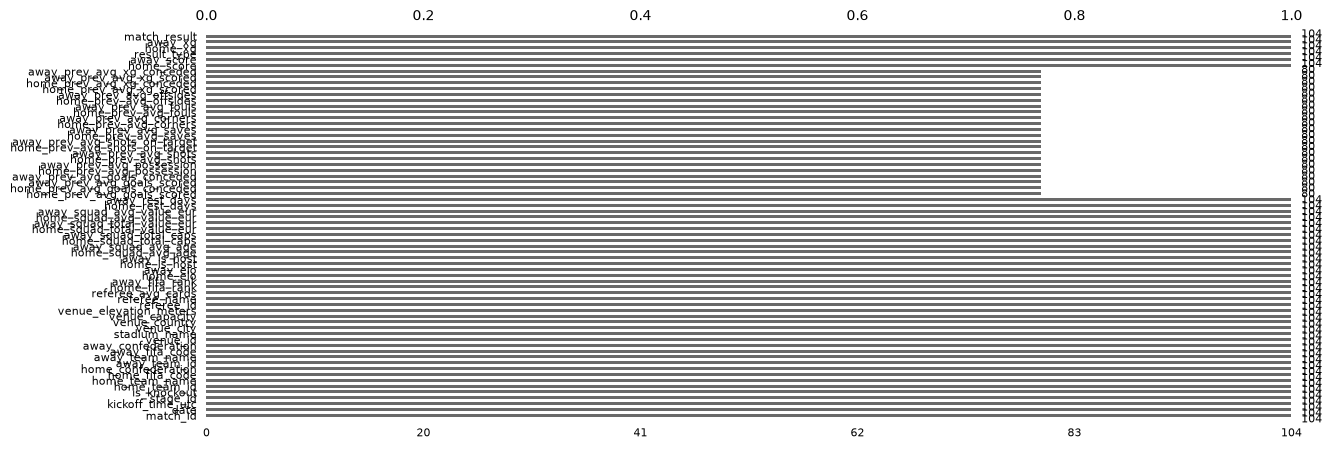

In [26]:
msno.bar(df_nan, figsize=(14, 5), fontsize=8)
plt.show()

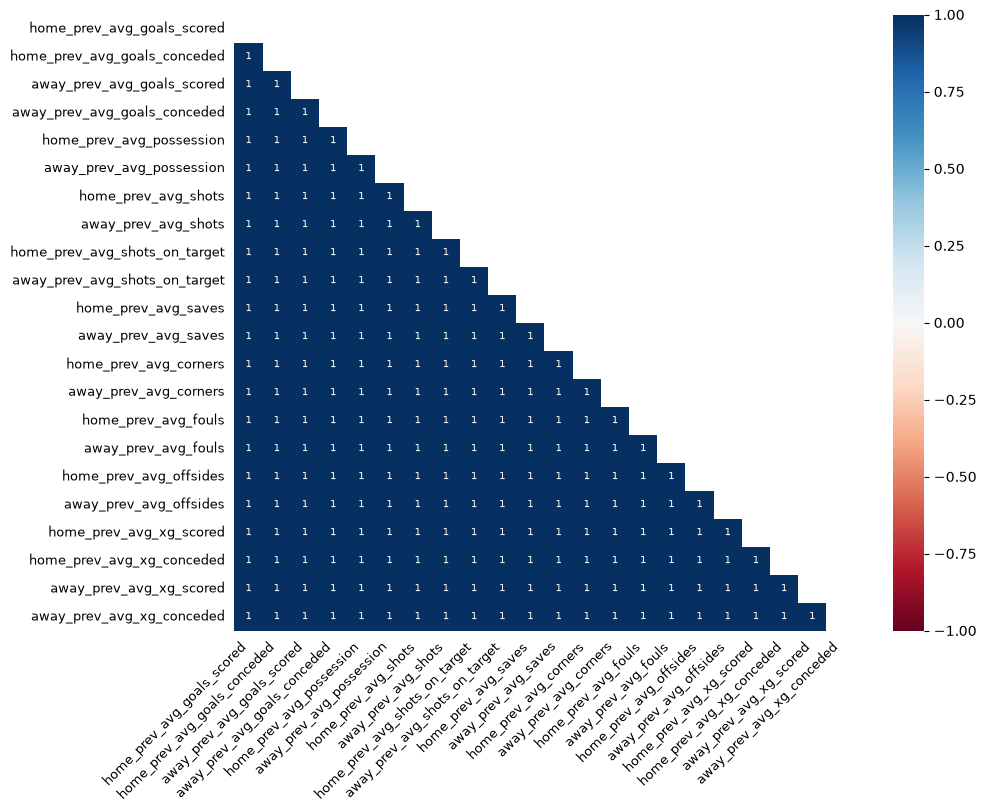

In [27]:
msno.heatmap(df_nan, figsize=(10, 8), fontsize=9)
plt.show()

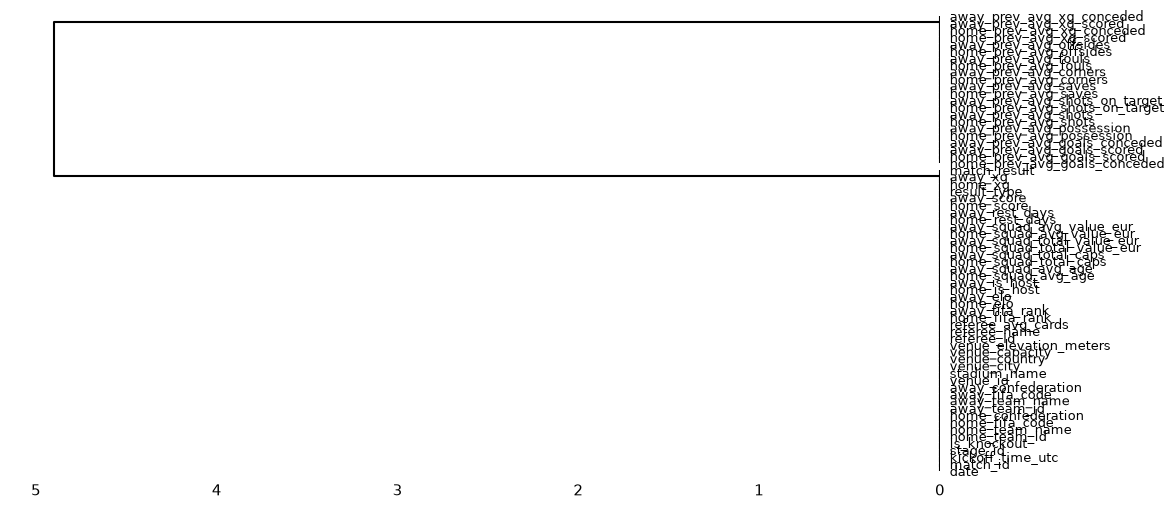

In [28]:
msno.dendrogram(df_nan, figsize=(12, 6), fontsize=9)
plt.show()

La matriz muestra un **bloque rectangular perfecto**: las 22 columnas previas faltan juntas, en las
mismas 24 filas del comienzo del dataset. Coherente con eso, el heatmap da correlación de nulidad `1`
entre todas ellas y el dendrograma las agrupa a distancia 0: son 22 columnas pero **un solo mecanismo
de faltante**.

### 4.4 Mecanismo del faltante (MCAR / MAR / MNAR)

Reutilizamos la función de la clase para medir el porcentaje de nulos dentro de cada grupo.

In [29]:
def nulos_por_grupo(df, grupo_cols, target_col):
    return (
        df.groupby(grupo_cols, observed=True)[target_col]
        .apply(lambda x: x.isnull().mean() * 100)
        .round(1)
        .reset_index(name=f'porcentaje_nulos_{target_col}')
    )

In [30]:
# ¿Depende de la fase del torneo?
nulos_por_grupo(df_nan, 'stage_id', 'home_prev_avg_xg_scored')

,stage_id,porcentaje_nulos_home_prev_avg_xg_scored
0,1,33.3
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0
5,6,0.0
6,7,0.0


In [31]:
# ¿Depende de los días de descanso?
nulos_por_grupo(df_nan, 'home_rest_days', 'home_prev_avg_xg_scored')

,home_rest_days,porcentaje_nulos_home_prev_avg_xg_scored
0,3.0,0.0
1,4.0,0.0
2,5.0,0.0
3,6.0,0.0
4,7.0,0.0
5,9.0,0.0
6,10.0,100.0


In [32]:
# ¿Depende de la confederación del equipo?
nulos_por_grupo(df_nan, 'home_confederation', 'home_prev_avg_xg_scored')

,home_confederation,porcentaje_nulos_home_prev_avg_xg_scored
0,AFC,63.6
1,CAF,15.4
2,CONCACAF,26.7
3,CONMEBOL,11.1
4,OFC,0.0
5,UEFA,20.0


Lecturas:

- **Por fase**: el 33,3 % de los partidos de fase de grupos tiene el dato faltante y **el 0 % de todas
  las fases eliminatorias**. Los nulos están perfectamente confinados.
- **Por días de descanso**: `rest_days == 10` → 100 % de nulos; cualquier otro valor → 0 %. La variable
  observada `rest_days` **determina** el faltante.
- **Por confederación**: va del 0 % (OFC) al 63,6 % (AFC). Tentador concluir que la confederación influye,
  pero es una correlación espuria: lo que cambia entre confederaciones es cuántas veces les tocó ser
  local en la primera fecha, no el mecanismo del faltante.

**Conclusión: es un faltante MAR, y de hecho un caso extremo (faltante estructural).** No es MCAR porque
la probabilidad de faltar no es uniforme, y no es MNAR porque no depende del valor no observado sino de
variables que sí tenemos: el dato falta si y solo si el equipo todavía no jugó ningún partido.

**Qué hacer con esto:**

1. **No imputar con la media** de la columna. Ya vamos a ver que el valor por defecto arrastra las medias
   y las correlaciones hacia abajo.
2. Agregar una **variable indicadora** `es_debut` (o directamente usar `rest_days == 10`) para que el
   modelo sepa que ese promedio no es información real.
3. Si el objetivo es predecir el resultado, una alternativa razonable es **imputar con un dato previo al
   torneo** (rendimiento en eliminatorias, Elo, ranking FIFA), que sí existe para las 48 selecciones.

## 5. Outliers

### 5.1 Detección por rango intercuartílico (IQR)

Se marca como atípico todo valor fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. Trabajamos sobre una selección
de variables (las 43 numéricas incluyen los 22 promedios previos, que ya sabemos que están contaminados).

In [33]:
cols_outliers = [
    'venue_capacity', 'venue_elevation_meters', 'referee_avg_cards',
    'home_fifa_rank', 'away_fifa_rank', 'home_elo', 'away_elo',
    'home_squad_avg_age', 'away_squad_avg_age', 'home_squad_total_caps',
    'home_squad_total_value_eur', 'home_rest_days',
    'home_prev_avg_possession', 'home_prev_avg_xg_scored',
    'home_score', 'away_score', 'home_xg', 'away_xg',
]

Q1 = df[cols_outliers].quantile(0.25)
Q3 = df[cols_outliers].quantile(0.75)
IQR = Q3 - Q1

limites = pd.DataFrame({'lim_inf': (Q1 - 1.5 * IQR), 'lim_sup': (Q3 + 1.5 * IQR)}).round(2)
es_outlier = (df[cols_outliers] < limites['lim_inf']) | (df[cols_outliers] > limites['lim_sup'])

limites['n_outliers'] = es_outlier.sum()
limites['pct'] = (100 * es_outlier.mean()).round(1)
limites.sort_values('n_outliers', ascending=False)

,lim_inf,lim_sup,n_outliers,pct
home_prev_avg_possession,3.825000e+01,6.925000e+01,10,9.6
venue_capacity,5.201400e+04,8.602200e+04,9,8.7
venue_elevation_meters,-3.766200e+02,6.483800e+02,9,8.7
away_xg,-7.100000e-01,2.740000e+00,5,4.8
home_squad_total_caps,3.883800e+02,1.493380e+03,3,2.9
home_prev_avg_xg_scored,2.300000e-01,2.890000e+00,2,1.9
home_xg,-9.200000e-01,3.770000e+00,2,1.9
home_score,-2.000000e+00,6.000000e+00,1,1.0
away_score,-3.000000e+00,5.000000e+00,1,1.0
away_fifa_rank,-4.900000e+01,1.110000e+02,0,0.0


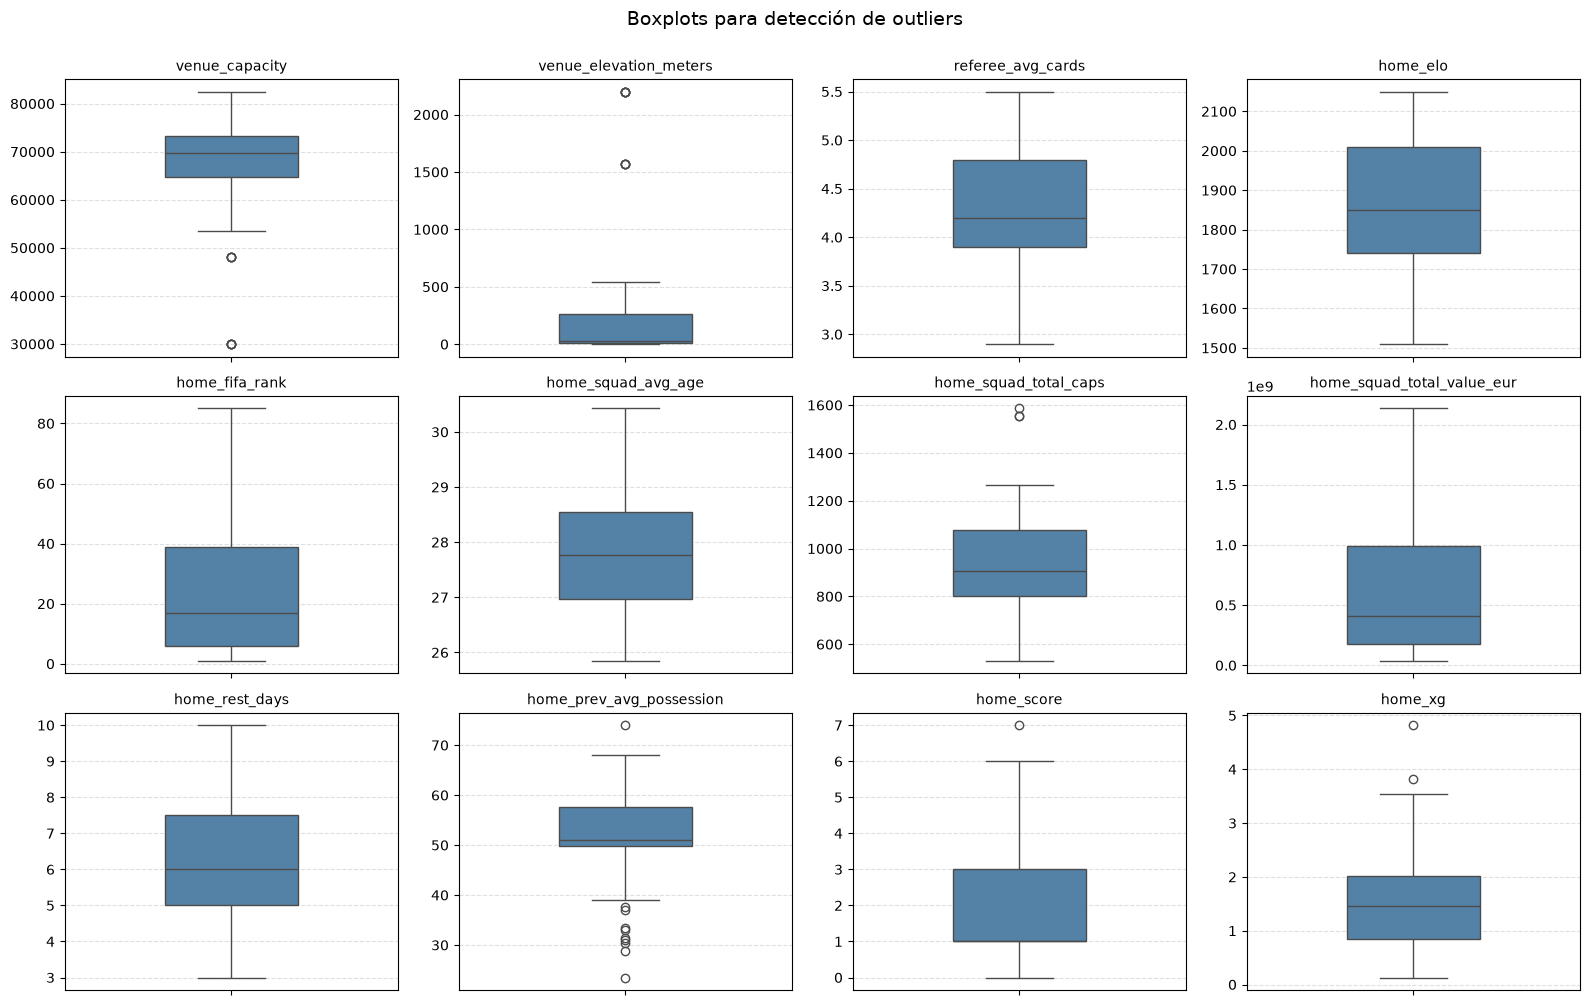

In [34]:
cols_box = ['venue_capacity', 'venue_elevation_meters', 'referee_avg_cards', 'home_elo',
            'home_fifa_rank', 'home_squad_avg_age', 'home_squad_total_caps',
            'home_squad_total_value_eur', 'home_rest_days', 'home_prev_avg_possession',
            'home_score', 'home_xg']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), cols_box):
    sns.boxplot(y=df[col], ax=ax, color='steelblue', width=0.4)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
    ax.grid(axis='y', ls='--', alpha=0.4)

fig.suptitle('Boxplots para detección de outliers', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### 5.2 Investigación de los outliers

Un valor atípico no es automáticamente un error. Hay que ir a mirar de qué fila se trata.

#### Sedes: altitud y capacidad

In [35]:
(elev_min, elev_max) = limites.loc['venue_elevation_meters', ['lim_inf', 'lim_sup']]
(cap_min, cap_max) = limites.loc['venue_capacity', ['lim_inf', 'lim_sup']]

print('--- Altitud fuera de rango ---')
print(df[df['venue_elevation_meters'] > elev_max][
    ['stadium_name', 'venue_city', 'venue_country', 'venue_elevation_meters']
].drop_duplicates().to_string(index=False))

print()
print('--- Capacidad fuera de rango ---')
print(df[(df['venue_capacity'] < cap_min) | (df['venue_capacity'] > cap_max)][
    ['stadium_name', 'venue_city', 'venue_country', 'venue_capacity']
].drop_duplicates().to_string(index=False))

--- Altitud fuera de rango ---
                        stadium_name  venue_city venue_country  venue_elevation_meters
Mexico City Stadium (Estadio Azteca) Mexico City           MEX                  2200.0
 Guadalajara Stadium (Estadio Akron)     Zapopan           MEX                  1566.0

--- Capacidad fuera de rango ---
                       stadium_name venue_city venue_country  venue_capacity
Guadalajara Stadium (Estadio Akron)    Zapopan           MEX           48070
        Toronto Stadium (BMO Field)    Toronto           CAN           30000


Los dos estadios con altitud atípica son el **Azteca (2200 m)** y el **Akron de Guadalajara (1566 m)**:
las sedes mexicanas del torneo. No son errores, y de hecho la altitud es una variable con efecto
deportivo real (fatiga, trayectoria de la pelota), así que conviene conservarla.

Las capacidades atípicas son el **BMO Field de Toronto (30.000)** por abajo y el **Akron (48.070)**:
estadios reales, más chicos que la media de sedes estadounidenses.

#### Resultados: goleadas

In [36]:
df['goles_totales'] = df['home_score'] + df['away_score']

df.nlargest(5, 'goles_totales')[
    ['date', 'stage_id', 'is_knockout', 'home_team_name', 'away_team_name',
     'home_score', 'away_score', 'result_type']
]

,date,stage_id,is_knockout,home_team_name,away_team_name,home_score,away_score,result_type
102,2026-07-18,6,1,France,England,4,6,Regular
8,2026-06-14,1,0,Germany,Curaçao,7,1,Regular
11,2026-06-14,1,0,Sweden,Tunisia,5,1,Regular
21,2026-06-17,1,0,England,Croatia,4,2,Regular
26,2026-06-18,1,0,Canada,Qatar,6,0,Regular


Los dos partidos que disparan los outliers de goles son legítimos pero extremos:

- **Alemania 7 – 1 Curaçao** en la primera fecha, la típica goleada de fase de grupos entre el equipo
  más caro del torneo y un debutante.
- **Francia 4 – 6 Inglaterra** con **10 goles**, y encima en tiempo reglamentario. Es el partido más
  goleador del dataset por lejos.

Vale la pena chequear que los partidos definidos por penales no tengan la tanda sumada al marcador, que
sería un error de carga clásico.

In [37]:
df[df['result_type'] != 'Regular'][
    ['date', 'stage_id', 'home_team_name', 'away_team_name',
     'home_score', 'away_score', 'result_type', 'match_result']
]

,date,stage_id,home_team_name,away_team_name,home_score,away_score,result_type,match_result
74,2026-06-30,2,Germany,Paraguay,1,1,Penalties,D
75,2026-06-30,2,Netherlands,Morocco,1,1,Penalties,D
80,2026-07-02,2,Belgium,Senegal,3,2,AET,H
85,2026-07-04,2,Australia,Egypt,1,1,Penalties,D
86,2026-07-04,2,Argentina,Cabo Verde,3,2,AET,H
98,2026-07-11,4,Norway,England,1,2,AET,A
99,2026-07-12,4,Argentina,Switzerland,3,1,AET,H
103,2026-07-19,7,Spain,Argentina,1,0,AET,H


Está bien cargado: los 3 partidos por penales figuran **1–1** y con `match_result = 'D'`, es decir, se
registra el resultado de los 90 minutos y la tanda no se suma al marcador. Los 5 partidos con alargue
tienen marcadores normales.

Ojo con el detalle de modelado que esto deja: **un partido que "gana" un equipo por penales aparece como
empate** en la variable objetivo. Es correcto desde lo estadístico, pero hay que tenerlo presente al
interpretar la clase `D`.

#### Promedios previos con pocos partidos de muestra

In [38]:
(pos_min, pos_max) = limites.loc['home_prev_avg_possession', ['lim_inf', 'lim_sup']]
atipicos_pos = (df['home_prev_avg_possession'] < pos_min) | (df['home_prev_avg_possession'] > pos_max)

df[atipicos_pos][['date', 'stage_id', 'home_team_name', 'away_team_name',
                  'home_prev_avg_possession']]

,date,stage_id,home_team_name,away_team_name,home_prev_avg_possession
38,2026-06-21,1,Spain,Saudi Arabia,74.000000
43,2026-06-22,1,Jordan,Algeria,33.000000
51,2026-06-24,1,Bosnia and Herzegovina,Qatar,31.500000
55,2026-06-25,1,Paraguay,Australia,23.500000
57,2026-06-26,1,Curaçao,Côte d'Ivoire,37.000000
65,2026-06-27,1,Cabo Verde,Saudi Arabia,30.500000
66,2026-06-27,1,Jordan,Argentina,31.000000
69,2026-06-28,1,Congo DR,Uzbekistan,33.500000
85,2026-07-04,2,Australia,Egypt,37.666667
88,2026-07-04,3,Paraguay,France,28.750000


**8 de los 10** valores atípicos de posesión previa están en la fase de grupos (`stage_id = 1`), donde el
promedio se calcula sobre **uno o dos partidos**. Un equipo que tuvo un solo partido con 23,5 % de
posesión queda como outlier, pero no porque el dato sea raro sino porque el promedio todavía no se
estabilizó. Es el mismo problema de fondo que los faltantes de la sección 4: **las variables `prev_avg`
tienen una confiabilidad que crece a medida que avanza el torneo**.

### 5.3 Comparación con el método de la desviación estándar

El criterio alternativo marca como atípico todo lo que caiga fuera de `media ± 3·σ`.

In [39]:
media = df[cols_outliers].mean()
desvio = df[cols_outliers].std()

outliers_std = (df[cols_outliers] - media).abs() > 3 * desvio

comparacion_metodos = pd.DataFrame({
    'IQR': es_outlier.sum(),
    'media ± 3σ': outliers_std.sum(),
})
comparacion_metodos['diferencia'] = comparacion_metodos['IQR'] - comparacion_metodos['media ± 3σ']

print(f"Total de valores marcados  ->  IQR: {es_outlier.sum().sum()}   "
      f"|   media ± 3σ: {outliers_std.sum().sum()}")
comparacion_metodos.sort_values('diferencia', ascending=False)

Total de valores marcados  ->  IQR: 42   |   media ± 3σ: 18


,IQR,media ± 3σ,diferencia
home_prev_avg_possession,10,1,9
venue_capacity,9,5,4
venue_elevation_meters,9,5,4
home_squad_total_caps,3,0,3
away_xg,5,2,3
home_prev_avg_xg_scored,2,1,1
home_xg,2,1,1
away_fifa_rank,0,0,0
home_elo,0,0,0
away_elo,0,0,0


### Conclusión sobre outliers

- El IQR marca **42** valores atípicos y el criterio de ±3σ solo **18**. La diferencia era esperable: con
  apenas 104 filas y varias distribuciones asimétricas, la media y el desvío ya están arrastrados por los
  propios valores extremos, así que ±3σ se vuelve muy poco sensible. Para este dataset el IQR es el
  criterio más informativo.
- **Ningún outlier resultó ser un error de carga.** Se explican todos por el dominio: dos sedes en altura,
  dos estadios chicos, dos goleadas y una tanda de penales bien registrada.
- **Técnica que aplicaría: ninguna eliminación ni winsorización.** Borrar el Azteca o el 7–1 sería tirar
  justamente los casos más informativos de un dataset de 104 filas. Lo razonable es:
  - usar **escalado robusto** (`RobustScaler`, basado en mediana e IQR) en lugar de `StandardScaler`;
  - aplicar **log** a las variables de dinero y a la altitud, que arrastran las colas más largas;
  - preferir modelos poco sensibles a extremos (árboles, *gradient boosting*) o regresión regularizada.
- El único grupo que sí requiere cuidado no es de outliers "reales" sino de **promedios calculados sobre
  muy pocos partidos** (`prev_avg` en fase de grupos), que conviene acompañar con una variable que indique
  cuántos partidos entraron en el promedio.

## 6. Gráficos y conclusiones

### 6.1 ¿Cuánto deforma la distribución el valor por defecto?

Cada variable previa tiene un pico artificial en el valor por defecto, formado por las 24 filas de debut.

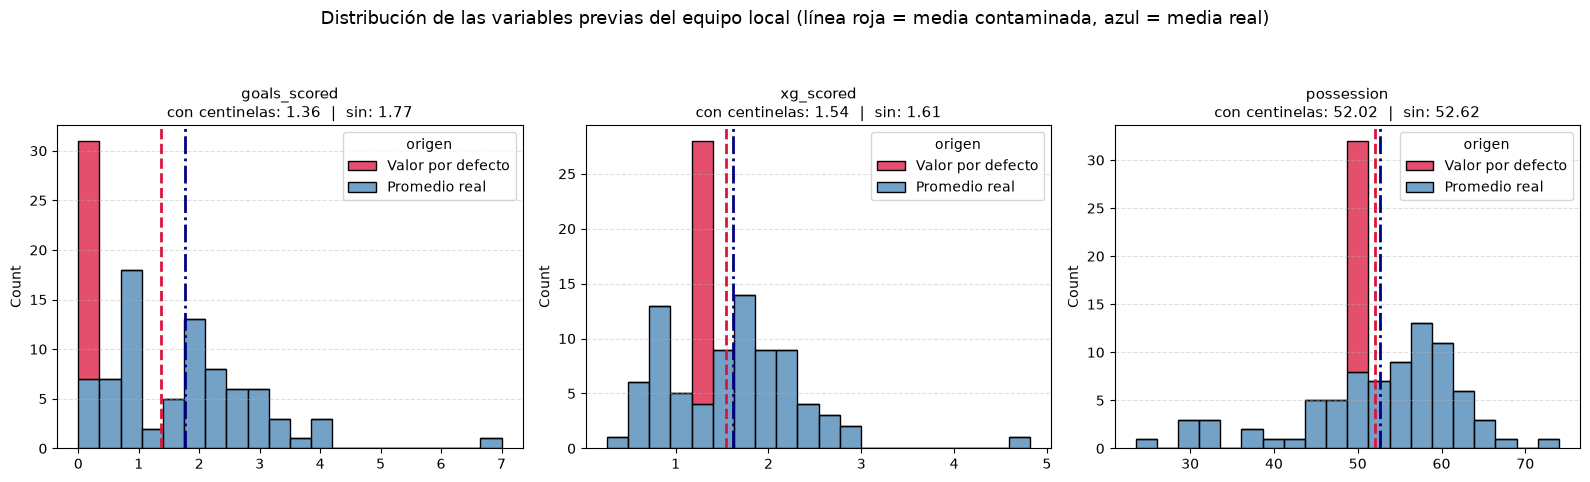

In [40]:
columnas_plot = ['home_prev_avg_goals_scored', 'home_prev_avg_xg_scored', 'home_prev_avg_possession']
tmp = df.assign(origen=np.where(debut_local, 'Valor por defecto', 'Promedio real'))
colores = {'Valor por defecto': 'crimson', 'Promedio real': 'steelblue'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, columnas_plot):
    sns.histplot(data=tmp, x=col, hue='origen', bins=20, multiple='stack',
                 palette=colores, ax=ax)
    media_con = df[col].mean()
    media_sin = df.loc[~debut_local, col].mean()
    ax.axvline(media_con, color='crimson', ls='--', lw=2)
    ax.axvline(media_sin, color='navy', ls='-.', lw=2)
    ax.set_title(f"{col.replace('home_prev_avg_', '')}\ncon centinelas: {media_con:.2f}  |  sin: {media_sin:.2f}",
                 fontsize=11)
    ax.set_xlabel('')
    ax.grid(axis='y', ls='--', alpha=0.4)

fig.suptitle('Distribución de las variables previas del equipo local (línea roja = media contaminada, azul = media real)',
             fontsize=13, y=1.06)
plt.tight_layout()
plt.show()

El caso más grave es `goals_scored`: el script rellenó con **0 goles**, así que 24 equipos que todavía no
habían jugado figuran como si no hubieran convertido nunca. La media pasa de 1,77 a 1,36 goles, un
**sesgo del −23 %** provocado íntegramente por datos que no existen.

### 6.2 El efecto sobre las correlaciones

El sesgo en la media es lo visible; lo que realmente rompe un modelo es que los centinelas **diluyen las
relaciones entre variables**, porque agregan 24 puntos que no siguen ningún patrón.

In [41]:
comparacion = pd.DataFrame({
    'media_con': df[prev_home].mean(),
    'media_sin': df.loc[~debut_local, prev_home].mean(),
    'corr_elo_con': df[prev_home].corrwith(df['home_elo']),
    'corr_elo_sin': df.loc[~debut_local, prev_home].corrwith(df.loc[~debut_local, 'home_elo']),
}).round(3)
comparacion['sesgo_media_%'] = ((comparacion['media_con'] / comparacion['media_sin'] - 1) * 100).round(1)
comparacion['delta_corr'] = (comparacion['corr_elo_sin'] - comparacion['corr_elo_con']).round(3)
comparacion.sort_values('delta_corr', ascending=False)

,media_con,media_sin,corr_elo_con,corr_elo_sin,sesgo_media_%,delta_corr
home_prev_avg_goals_scored,1.362,1.771,0.345,0.436,-23.1,0.091
home_prev_avg_xg_scored,1.542,1.614,0.573,0.655,-4.5,0.082
home_prev_avg_possession,52.015,52.620,0.574,0.652,-1.1,0.078
home_prev_avg_shots_on_target,4.849,5.104,0.473,0.539,-5.0,0.066
home_prev_avg_corners,5.096,5.125,0.396,0.452,-0.6,0.056
home_prev_avg_offsides,1.682,1.587,0.140,0.186,6.0,0.046
home_prev_avg_shots,13.583,14.058,0.335,0.377,-3.4,0.042
home_prev_avg_fouls,10.735,10.356,-0.166,-0.177,3.7,-0.011
home_prev_avg_saves,2.983,2.978,-0.382,-0.436,0.2,-0.054
home_prev_avg_xg_conceded,1.190,1.157,-0.548,-0.622,2.9,-0.074


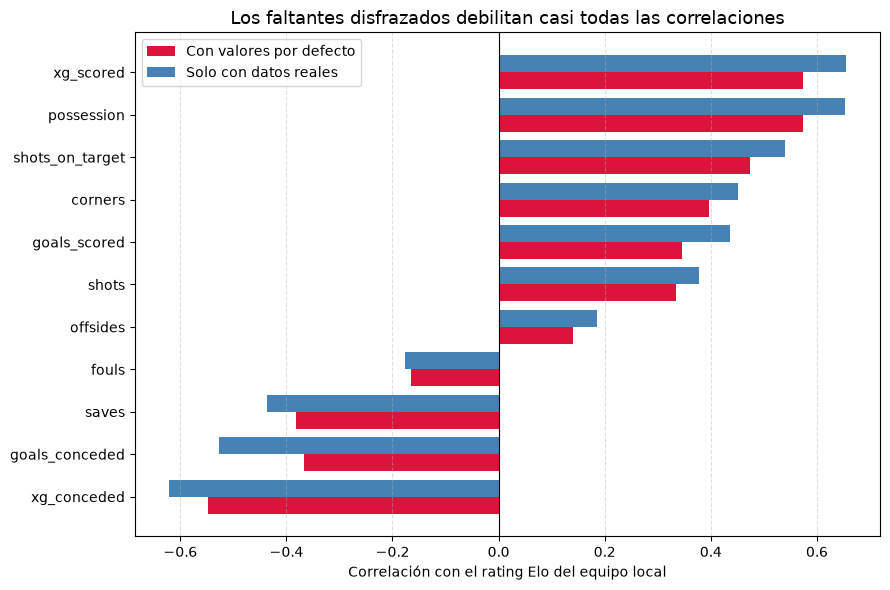

In [42]:
orden = comparacion.sort_values('corr_elo_sin')
etiquetas = [c.replace('home_prev_avg_', '') for c in orden.index]
y = np.arange(len(orden))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y - 0.2, orden['corr_elo_con'], height=0.4, color='crimson', label='Con valores por defecto')
ax.barh(y + 0.2, orden['corr_elo_sin'], height=0.4, color='steelblue', label='Solo con datos reales')
ax.set_yticks(y)
ax.set_yticklabels(etiquetas)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlación con el rating Elo del equipo local')
ax.set_title('Los faltantes disfrazados debilitan casi todas las correlaciones', fontsize=13)
ax.grid(axis='x', ls='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión.** En **las 11 variables** la correlación se vuelve más fuerte en valor absoluto al sacar los
24 partidos contaminados: las positivas suben y las negativas bajan. La señal siempre estaba ahí, los
centinelas la tapaban. Dos ejemplos concretos:

- `xg_scored` vs Elo: sube de **0,57 a 0,66**.
- `goals_conceded` vs Elo: baja de **−0,37 a −0,53** (los equipos fuertes reciben menos goles, y con los
  centinelas adentro esa relación se veía casi la mitad de fuerte).

Y el caso más llamativo es la correlación entre lo que un equipo venía convirtiendo y lo que convierte en
el partido:

In [43]:
objetivo = 'home_score'
for col in ['home_prev_avg_goals_scored', 'home_prev_avg_xg_scored', 'home_prev_avg_shots_on_target']:
    con = df[col].corr(df[objetivo])
    sin = df.loc[~debut_local, col].corr(df.loc[~debut_local, objetivo])
    print(f"{col.replace('home_prev_avg_', ''):<22} corr con {objetivo}:  "
          f"con centinelas {con:+.3f}   |   solo datos reales {sin:+.3f}")

goals_scored           corr con home_score:  con centinelas -0.005   |   solo datos reales +0.092
xg_scored              corr con home_score:  con centinelas +0.163   |   solo datos reales +0.225
shots_on_target        corr con home_score:  con centinelas +0.102   |   solo datos reales +0.154


`goals_scored` pasa de **−0,005 a +0,092**: **cambia de signo**. Con los centinelas adentro la lectura
sería "los goles previos no tienen ninguna relación con los goles del partido", y eso es un artefacto del
relleno, no un hallazgo.

Es el argumento práctico contra imputar a ciegas: un valor por defecto mal elegido no solo mueve un
promedio, puede invertir la interpretación de una relación.

### 6.3 Curiosidad: ¿el Elo predice el resultado?

Ya limpio el panorama de faltantes, una pregunta sobre las variables que **sí** están completas para los
104 partidos: ¿el rating Elo previo anticipa quién gana?

In [44]:
df['elo_diff'] = df['home_elo'] - df['away_elo']

favorito_gana = (((df['elo_diff'] > 0) & (df['match_result'] == 'H')) |
                 ((df['elo_diff'] < 0) & (df['match_result'] == 'A')))
sin_empate = df['match_result'] != 'D'

print(f"El favorito según Elo gana en {favorito_gana.sum()} de {len(df)} partidos "
      f"({100 * favorito_gana.mean():.1f} %)")
print(f"Si descartamos los {int((~sin_empate).sum())} empates: "
      f"{100 * favorito_gana[sin_empate].mean():.1f} %")
print()
print(df['match_result'].value_counts(normalize=True).mul(100).round(1).to_string())

El favorito según Elo gana en 70 de 104 partidos (67.3 %)
Si descartamos los 24 empates: 87.5 %

match_result
H    48.1
A    28.8
D    23.1


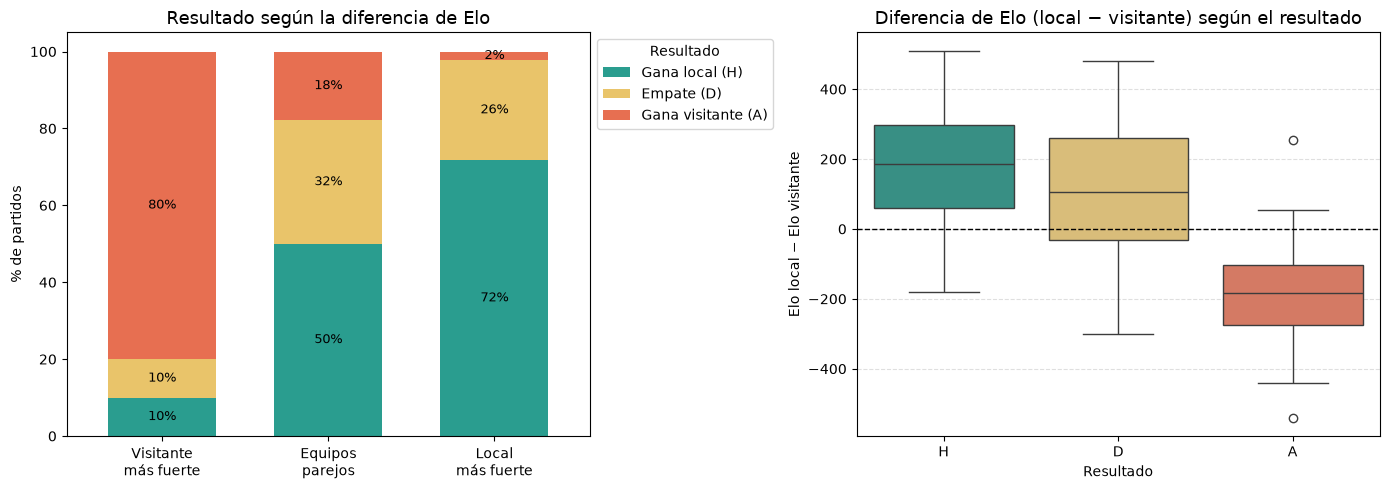

In [45]:
franjas = pd.cut(df['elo_diff'], [-np.inf, -100, 100, np.inf],
                 labels=['Visitante\nmás fuerte', 'Equipos\nparejos', 'Local\nmás fuerte'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tabla = pd.crosstab(franjas, df['match_result'], normalize='index').mul(100)
tabla = tabla[['H', 'D', 'A']]
tabla.plot(kind='bar', stacked=True, ax=axes[0],
           color=['#2a9d8f', '#e9c46a', '#e76f51'], width=0.65)
axes[0].set_title('Resultado según la diferencia de Elo', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('% de partidos')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Resultado', labels=['Gana local (H)', 'Empate (D)', 'Gana visitante (A)'],
               bbox_to_anchor=(1.0, 1.0))
for cont in axes[0].containers:
    axes[0].bar_label(cont, fmt='%.0f%%', label_type='center', fontsize=9)

sns.boxplot(data=df, x='match_result', y='elo_diff', order=['H', 'D', 'A'],
            palette=['#2a9d8f', '#e9c46a', '#e76f51'], hue='match_result',
            legend=False, ax=axes[1])
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].set_title('Diferencia de Elo (local − visitante) según el resultado', fontsize=13)
axes[1].set_xlabel('Resultado')
axes[1].set_ylabel('Elo local − Elo visitante')
axes[1].grid(axis='y', ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Conclusión.** El Elo es un predictor fuerte pero no perfecto: acierta el **67,3 %** de los 104 partidos
y el **87,5 %** si se descartan los empates. El boxplot muestra la escala del efecto: cuando gana el local
la diferencia de Elo mediana es claramente positiva, cuando gana el visitante es claramente negativa, y
los empates se concentran alrededor del 0 con mucha dispersión.

**La curiosidad.** Los empates son el verdadero punto ciego. En la franja de equipos parejos hay un 25 %
de empates, pero en la franja donde el local es mucho más fuerte hay un **26 %**: prácticamente el mismo.
La diferencia de Elo dice bastante sobre *quién* gana, pero casi nada sobre *si* alguien gana. Es
exactamente lo que se ve en el pairplot de la sección 3.2, donde la nube de empates queda superpuesta a
las otras dos. Cualquier modelo que se construya sobre este dataset va a acertar los favoritos y va a
sufrir con la clase `D`.

## 7. Desafíos a priori y técnicas a aplicar

### 7.1 Fuga de información (*data leakage*)

El desafío más importante y el más fácil de pasar por alto. El archivo se llama
`match_prediction_features`, pero **cinco de sus columnas solo existen una vez que el partido terminó**:
`home_score`, `away_score`, `home_xg`, `away_xg` y `result_type`.

In [46]:
resultado_derivado = np.where(df['home_score'] > df['away_score'], 'H',
                     np.where(df['home_score'] < df['away_score'], 'A', 'D'))

print("¿match_result se deduce exactamente de los goles?",
      bool((resultado_derivado == df['match_result']).all()))

posteriores = ['home_score', 'away_score', 'home_xg', 'away_xg', 'result_type']
originales = pd.read_csv(path).columns.tolist()   # sin las columnas derivadas en el análisis

print()
print(f"Columnas del archivo original:        {len(originales)}")
print(f"  - identificadores:                  {len(ids)}")
print(f"  - variable objetivo (match_result): 1")
print(f"  - posteriores al partido:           {len(posteriores)}  {posteriores}")
print(f"Features realmente utilizables:       "
      f"{len(originales) - len(ids) - 1 - len(posteriores)} para {len(df)} partidos")

¿match_result se deduce exactamente de los goles? True

Columnas del archivo original:        66
  - identificadores:                  6
  - variable objetivo (match_result): 1
  - posteriores al partido:           5  ['home_score', 'away_score', 'home_xg', 'away_xg', 'result_type']
Features realmente utilizables:       54 para 104 partidos


`match_result` se deduce **al 100 %** de `home_score` y `away_score`. Un modelo entrenado con esas
columnas adentro daría una accuracy perfecta y sería completamente inútil. Hay que sacarlas de `X` — de
hecho el propio dataset ya trae un `match_prediction_features_X.csv` separado del
`match_prediction_targets_y.csv`, señal de que el problema estaba previsto.

### 7.2 Pocas filas para tantas columnas

104 partidos y 66 columnas. Descontando los 6 identificadores, la variable objetivo y las 5 posteriores
al partido, quedan **54 features para 104 observaciones**: una relación de apenas 2 filas por variable.
Es territorio de sobreajuste casi garantizado.

**Técnicas:** selección de variables agresiva, regularización fuerte (Ridge/Lasso, `max_depth` bajo),
y sobre todo **validación cruzada estratificada repetida** en lugar de un `train_test_split` simple —
con 104 filas, un split 80/20 deja 21 partidos de test y cualquier métrica sobre eso es puro ruido.

### 7.3 Redundancia entre variables

In [47]:
numericas_reales = df.select_dtypes('number').drop(
    columns=ids + ['goles_totales', 'elo_diff'], errors='ignore')

matriz = numericas_reales.corr().abs().to_numpy(copy=True)
nombres = numericas_reales.corr().columns
matriz[np.triu_indices_from(matriz, 0)] = np.nan

pares = (pd.DataFrame(matriz, index=nombres, columns=nombres)
         .stack()
         .sort_values(ascending=False))

print(f"Pares con |r| > 0.9: {(pares > 0.9).sum()}   |   con |r| > 0.8: {(pares > 0.8).sum()}")
pares[pares > 0.9].round(3).to_frame('|r|')

Pares con |r| > 0.9: 5   |   con |r| > 0.8: 13


,,|r|
away_squad_avg_value_eur,away_squad_total_value_eur,1.000
home_squad_avg_value_eur,home_squad_total_value_eur,1.000
away_rest_days,home_rest_days,0.965
away_elo,away_fifa_rank,0.932
home_elo,home_fifa_rank,0.929


Hay redundancia estructural, no casual:

- `squad_avg_value_eur` y `squad_total_value_eur` correlacionan **1,000**: una es la otra dividida por el
  tamaño del plantel, que es fijo. Una de las dos sobra.
- `elo` y `fifa_rank` correlacionan **0,93**: miden lo mismo con distinta escala.
- `home_rest_days` y `away_rest_days` correlacionan **0,97**, porque los dos equipos juegan el mismo día.

Además el dataset tiene **estructura espejada**: casi toda variable `home_*` tiene su `away_*`.

**Técnicas:** eliminar las duplicadas exactas y, sobre todo, **colapsar los pares en variables
diferencia** (`elo_diff = home_elo − away_elo`, `value_ratio`, `rank_diff`). Eso baja la dimensionalidad
a la mitad y además captura mejor lo que importa, que es el desequilibrio entre los dos equipos, no el
valor absoluto de cada uno.

### 7.4 Alta cardinalidad en las categóricas

`home_team_name` y `away_team_name` tienen 48 categorías para 104 filas: con *one-hot* se agregarían 96
columnas casi vacías. `referee_name` (28) y `venue_city` (16) tienen el mismo problema en menor escala.

**Técnicas:**

- **One-hot** solo para las de baja cardinalidad: `confederation` (6), `venue_country` (3), `is_knockout`.
- Para los equipos, **no codificar el nombre**: ya están representados por Elo, ranking FIFA, valor de
  plantel y confederación, que son mucho más informativos y generalizan a equipos no vistos.
- Si aun así se quisiera usarlos, *target encoding* con suavizado (`category_encoders`), nunca *one-hot*.

### 7.5 Faltantes estructurales y confiabilidad variable

Lo de la sección 4: las 22 columnas `prev_avg` no tienen valor real para los 24 partidos de la primera
fecha, y para la segunda y tercera fecha son promedios de uno o dos partidos.

**Técnicas:** agregar `es_debut` y `n_partidos_previos` como variables explícitas, e imputar el debut con
información previa al torneo (rendimiento en eliminatorias) en vez de con la media de la columna.

### 7.6 La clase `D` y la métrica de evaluación

El target está balanceado en frecuencia (48 % / 23 % / 29 %, entropía 0,95 sobre 1) pero **no es
separable**: en la sección 6.3 vimos que la proporción de empates es prácticamente la misma entre equipos
parejos (25 %) y entre equipos muy desparejos (26 %), y en el pairplot de la 3.2 la nube de empates está
totalmente superpuesta con las otras dos.

**Técnicas:** evaluar con **F1 macro o balanced accuracy**, no con accuracy — un modelo que nunca predice
`D` ya alcanza ~77 % de accuracy y sería un mal modelo. Reportar la matriz de confusión completa y
considerar reformular el problema como binario (gana local sí/no) si el objetivo lo permite.

### 7.7 Resumen

| Desafío | Severidad | Técnica propuesta |
|---|---|---|
| Leakage de `score`, `xg`, `result_type` | **Crítica** | Excluirlas de `X` |
| 54 features / 104 filas | Alta | Regularización + CV estratificada repetida |
| 5 pares con \|r\| > 0,9 y estructura espejada | Alta | Variables diferencia `home − away` |
| 48 categorías en los nombres de equipo | Media | No codificarlos; usar Elo / valor / confederación |
| Faltantes estructurales del debut | Media | `es_debut` + imputación con datos pre-torneo |
| Clase `D` no separable | Media | F1 macro; evaluar reformulación binaria |
| Asimetría y outliers legítimos | Baja | `RobustScaler` + log en dinero y altitud |
| 80 % de los partidos en USA | Baja | Poco poder discriminante en `venue_country` |